# Модуль 13. TD-обучение и дофамин

Ноутбук к [модулю 13](https://drobyshevdev.github.io/lemma/modules/13-td-learning-and-dopamine/).

Обучение временными разностями руками: ценность учится по одному переходу, всплеск ошибки предсказания переезжает с награды на сигнал, три случая Шульца выходят как знак δ. Только `numpy` и `matplotlib`.

**Читайте дважды:** сначала целиком, потом ломая.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
np.set_printoptions(precision=3, suppress=True)

## 1. Проба и TD(0)

Проба: в момент **сигнала** зажигается лампа, через несколько шагов приходит **награда**. Состояния до сигнала держим на нуле — это «нет стимула», они ничего не предсказывают, поэтому ценность распространяется назад только до сигнала.

Ошибка предсказания: $\delta_t = r_t + \gamma V_{t+1} - V_t$. Обновление: $V_t \leftarrow V_t + \alpha\,\delta_t$.

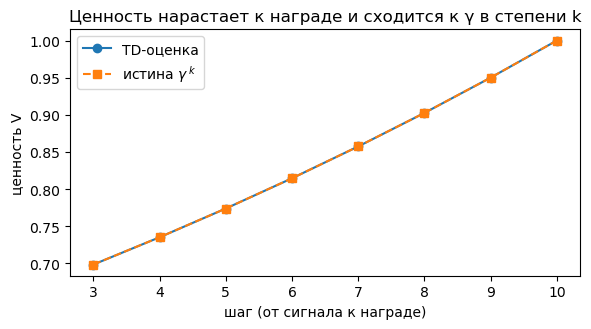

макс. отклонение TD от истины: 0.0000


In [2]:
T, CUE, REWARD = 14, 3, 10
gamma, alpha = 0.95, 0.3

def run(trials, V=None, omit=()):
    if V is None:
        V = np.zeros(T)
    deltas = np.zeros((trials, T))
    for k in range(trials):
        give = k not in omit
        for t in range(CUE - 1, T):
            r = 1.0 if (t == REWARD and give) else 0.0
            v_next = V[t + 1] if t + 1 < T else 0.0
            d = r + gamma * v_next - V[t]
            deltas[k, t] = d
            if t >= CUE and give:                 # нулевые состояния до сигнала не учим
                V[t] += alpha * d
    return V, deltas

V, deltas = run(80)
ks = np.arange(CUE, REWARD + 1)
true = gamma ** (REWARD - ks)                     # точная ценность: дисконт по числу шагов до награды

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(ks, V[CUE:REWARD + 1], "o-", label="TD-оценка")
ax.plot(ks, true, "s--", label=r"истина $\gamma^{\,k}$")
ax.set_xlabel("шаг (от сигнала к награде)"); ax.set_ylabel("ценность V")
ax.set_title("Ценность нарастает к награде и сходится к γ в степени k")
ax.legend(); plt.tight_layout(); plt.show()
print("макс. отклонение TD от истины: %.4f" % np.max(np.abs(V[CUE:REWARD + 1] - true)))

TD-оценка легла на $\gamma^{k}$: чем ближе шаг к награде, тем выше ценность, ровно как дисконт из модуля 12, только выученный по опыту, без модели среды.

**Сломать.** Уменьшите `alpha` до 0.05 — сходимость станет медленнее и глаже; поднимите до 0.8 — быстрее, но оценка задрожит. Это та же длина шага, что в модуле 4.

## 2. Сдвиг сигнала δ

Тепловая карта ошибки: строка — проба, столбец — момент времени. Смотрим, куда садится всплеск.

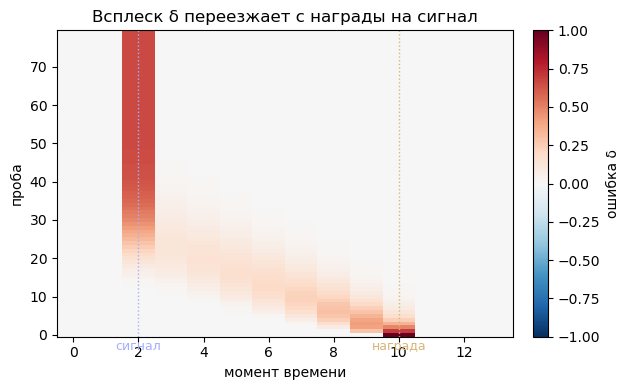

проба 1: всплеск на t = 10 (награда)   проба 80: всплеск на t = 2 (сигнал)


In [3]:
fig, ax = plt.subplots(figsize=(6.4, 4))
m = np.abs(deltas).max()
im = ax.imshow(deltas, aspect="auto", cmap="RdBu_r", vmin=-m, vmax=m, origin="lower")
ax.axvline(CUE - 1, color="#a5b0ff", ls=":", lw=1); ax.axvline(REWARD, color="#d8b678", ls=":", lw=1)
ax.text(CUE - 1, -4, "сигнал", ha="center", color="#a5b0ff", fontsize=9)
ax.text(REWARD, -4, "награда", ha="center", color="#d8b678", fontsize=9)
ax.set_xlabel("момент времени"); ax.set_ylabel("проба")
ax.set_title("Всплеск δ переезжает с награды на сигнал")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="ошибка δ")
plt.tight_layout(); plt.show()

first = int(np.argmax(deltas[0]))
last = int(np.argmax(deltas[-1]))
print("проба 1: всплеск на t =", first, "(награда)   проба 80: всплеск на t =", last, "(сигнал)")

Яркая полоса начинает у награды и с пробами сползает влево, к сигналу. На первых пробах награда — сюрприз; на последних её предсказал сигнал, и вся неожиданность переехала туда.

**Сломать.** Раздвиньте сигнал и награду (`CUE = 2, REWARD = 12`) — полоса поедет дольше: чем длиннее задержка, тем больше проб уходит на сдвиг.

## 3. Три случая Шульца

Знак δ в трёх ситуациях, которые записали с дофаминовых нейронов в 1997 году.

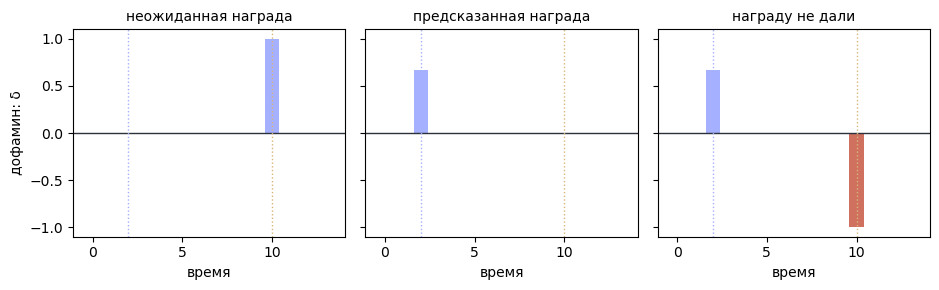

неожиданная: δ на награде = 1.00
предсказанная: δ на сигнале = 0.66, на награде = 0.00
не дали: δ на месте награды = -1.00


In [4]:
V_naive = np.zeros(T)                              # необученная модель
_, d_unexpected = run(1, V_naive.copy())           # награда без предсказания
V_trained, _ = run(200)                            # обучаем до насыщения
_, d_predicted = run(1, V_trained.copy())          # предсказанная награда
_, d_omitted = run(1, V_trained.copy(), omit={0})  # предсказанную награду не дали

fig, axes = plt.subplots(1, 3, figsize=(9.5, 3), sharey=True)
cases = [("неожиданная награда", d_unexpected[0]),
         ("предсказанная награда", d_predicted[0]),
         ("награду не дали", d_omitted[0])]
for ax, (title, d) in zip(axes, cases):
    colors = ["#a5b0ff" if x >= 0 else "#d0705f" for x in d]
    ax.bar(range(T), d, color=colors)
    ax.axhline(0, color="#2c313b", lw=1)
    ax.axvline(CUE - 1, color="#a5b0ff", ls=":", lw=1); ax.axvline(REWARD, color="#d8b678", ls=":", lw=1)
    ax.set_title(title, fontsize=10); ax.set_xlabel("время")
axes[0].set_ylabel("дофамин: δ")
plt.tight_layout(); plt.show()

print("неожиданная: δ на награде = %.2f" % d_unexpected[0, REWARD])
print("предсказанная: δ на сигнале = %.2f, на награде = %.2f" % (d_predicted[0, CUE - 1], d_predicted[0, REWARD]))
print("не дали: δ на месте награды = %.2f" % d_omitted[0, REWARD])

Три знака δ, три записи Шульца. Неожиданная награда — всплеск на ней. Предсказанная — всплеск на сигнале, ноль на награде. Пропущенная — провал ниже фона там, где её ждали. Дофамин кодирует не награду, а её неожиданность.

**Сломать.** Обучите на награде 1.0, а в проверке дайте 2.0 (удвоенную). Появится положительная δ на награде: она снова стала сюрпризом, только приятным.

## 4. TD против Монте-Карло

TD учится по догадке (бутстрэп), Монте-Карло ждёт конца и учит по фактической отдаче. Сравним на **шумной** награде: она приходит не всегда. Истинная ценность тогда — вероятность награды на дисконт.

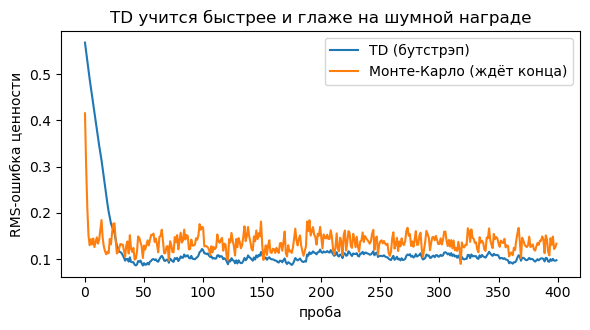

ошибка на 50-й пробе -- TD: 0.091   MC: 0.129


In [5]:
p_reward = 0.7
true_v = p_reward * gamma ** (REWARD - np.arange(CUE, REWARD + 1))

def td_run(trials, seed):
    g = np.random.default_rng(seed); V = np.zeros(T); err = []
    for _ in range(trials):
        got = g.random() < p_reward
        for t in range(CUE, T):
            r = 1.0 if (t == REWARD and got) else 0.0
            d = r + gamma * (V[t + 1] if t + 1 < T else 0.0) - V[t]
            V[t] += alpha * d
        err.append(np.sqrt(np.mean((V[CUE:REWARD + 1] - true_v) ** 2)))
    return err

def mc_run(trials, seed):
    g = np.random.default_rng(seed); V = np.zeros(T); err = []
    for _ in range(trials):
        got = g.random() < p_reward
        for t in range(CUE, REWARD + 1):
            G = (gamma ** (REWARD - t)) * (1.0 if got else 0.0)   # фактическая отдача до конца
            V[t] += alpha * (G - V[t])
        err.append(np.sqrt(np.mean((V[CUE:REWARD + 1] - true_v) ** 2)))
    return err

trials = 400
td = np.mean([td_run(trials, s) for s in range(30)], axis=0)
mc = np.mean([mc_run(trials, s) for s in range(30)], axis=0)

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(td, label="TD (бутстрэп)")
ax.plot(mc, label="Монте-Карло (ждёт конца)")
ax.set_xlabel("проба"); ax.set_ylabel("RMS-ошибка ценности")
ax.set_title("TD учится быстрее и глаже на шумной награде")
ax.legend(); plt.tight_layout(); plt.show()
print("ошибка на 50-й пробе -- TD: %.3f   MC: %.3f" % (td[50], mc[50]))

TD спускается к истине быстрее и ровнее: он подмешивает крупицу правды на каждом переходе, а не ждёт целого эпизода. Плата — смещение от бутстрэпа на старте, пока оценки, по которым он учится, сами неверны. Это тот же обмен «шум против ожидания», что размер батча в модуле 4.

## Что дальше

TD выучил ценность. Чтобы получить **политику**, ошибку δ используют как сигнал: в [модуле 14](https://drobyshevdev.github.io/lemma/programme/) она станет критиком, а градиент из модуля 4 — актором. И там же — почему в RL воспроизводимость особенно плоха, и как её проверяют бутстрэпом на зёрнах из модуля 1.